In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("/content/spam_email_dataset.csv")

In [35]:
df

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,🔥WIN BIG NOW!!,free win cash win guarantee urgent free win li...,22,136,0,5,1,0,0,fefsrcz@unknownmail.cc,unknownmail.cc,0.68,8,1,0,29,1,1,1
9996,9996,You are selected!!!,click now free guarantee free win click now wi...,26,158,0,2,0,0,0,yxyctux@chealdealz.xyz,chealdealz.xyz,0.76,2,3,0,29,0,1,1
9997,9997,You are selected!!!,offer cash win limited click now cash limited ...,21,124,0,3,1,1,1,tkvqnki@unknownmail.cc,unknownmail.cc,0.69,6,1,0,25,0,1,1
9998,9998,Meeting Reminder,budget review - Many result affect idea.,7,40,0,1,0,2,1,wmvnrbn@outlook.com,outlook.com,0.80,7,2,0,18,0,0,0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   email_id                 10000 non-null  int64  
 1   subject                  10000 non-null  object 
 2   email_text               10000 non-null  object 
 3   num_words                10000 non-null  int64  
 4   num_characters           10000 non-null  int64  
 5   num_exclamation_marks    10000 non-null  int64  
 6   num_links                10000 non-null  int64  
 7   has_suspicious_link      10000 non-null  int64  
 8   num_attachments          10000 non-null  int64  
 9   has_attachment           10000 non-null  int64  
 10  sender_email             10000 non-null  object 
 11  sender_domain            10000 non-null  object 
 12  sender_reputation_score  10000 non-null  float64
 13  email_hour               10000 non-null  int64  
 14  email_day_of_week      

In [37]:
df.isnull().sum()

,0
email_id,0
subject,0
email_text,0
num_words,0
num_characters,0
num_exclamation_marks,0
num_links,0
has_suspicious_link,0
num_attachments,0
has_attachment,0


In [38]:
print(df.duplicated().sum())
print(df['email_text'].duplicated().sum())

0
0


In [39]:
cols  = df.select_dtypes(include = 'object').columns
cols

Index(['subject', 'email_text', 'sender_email', 'sender_domain'], dtype='object')

In [40]:
for col in cols:
  df[col] = df[col].apply(lambda x: x.lower())
  df[col] = df[col].str.strip()
  print(df[col].nunique())
  print(df[col].value_counts())
  print(" ----------------------------------")

8
subject
schedule confirmation       1553
project update              1510
meeting reminder            1489
weekly report               1453
urgent: cliam your prize    1021
🔥win big now!!              1002
you are selected!!!          993
limited offer!!!             979
Name: count, dtype: int64
 ----------------------------------
10000
email_text
win guarantee cash click now free limited fly why change chair church benefit film animal mean event fund where bar behavior.                                  1
guarantee offer win urgent click now urgent guarantee win limited free win cash offer limited limited already minute environment book section it.              1
offer urgent guarantee urgent urgent limited girl matter once charge personal sister thank plan where.                                                         1
schedule - believe stop cup might view. black this why energy game like foot.                                                                                  1
urg

In [41]:
df_edited = df.copy()
df_edited = df_edited.rename(columns={'label': 'is_spam'})

In [42]:
df_edited = df_edited.drop(columns = ['email_id' , 'sender_email' , 'num_exclamation_marks'])

In [43]:
df.head()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,weekly report,budget review - statement our i claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,project update,team sync - president series today already. in...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥win big now!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥win big now!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,meeting reminder,team sync - significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [44]:
import string

def remove_punch(text):
  return text.translate(str.maketrans('', '', string.punctuation))

cols = df_edited.select_dtypes(include = 'object').columns

for col in cols:
  df_edited[col] = df_edited[col].apply(remove_punch)



In [45]:
def remove_emoji(text):
  new = ""
  for i in text:
    if i.isascii():
      new += i
  return new

for col in cols:
  df_edited[col] = df_edited[col].apply(remove_emoji)

df_edited.head()

,subject,email_text,num_words,num_characters,num_links,has_suspicious_link,num_attachments,has_attachment,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,is_spam
0,weekly report,budget review statement our i claim world sta...,19,114,2,0,2,1,outlookcom,0.66,19,3,0,23,0,0,0
1,project update,team sync president series today already invo...,18,114,7,0,0,0,companycom,0.95,4,4,0,16,1,0,0
2,win big now,win free urgent offer limited limited urgent u...,19,126,4,1,1,1,unknownmailcc,0.68,3,0,0,10,1,1,1
3,win big now,guarantee click now cash offer click now guara...,16,101,7,1,1,1,chealdealzxyz,0.69,19,5,1,25,1,1,1
4,meeting reminder,team sync significant property hotel not addr...,18,111,7,1,2,1,yahoocom,0.67,4,5,1,8,0,0,0


In [46]:
import nltk
from nltk.corpus import stopwords

In [47]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [48]:
stop_word = set(stopwords.words('english'))

def remove_txt(text):
  words = nltk.word_tokenize(text)
  return ' '.join([word for word in words if word not in stop_word])


cols = ['subject' , 'email_text'];

for col in cols:
  df_edited[col] = df_edited[col].apply(remove_txt)

df_edited.head()

,subject,email_text,num_words,num_characters,num_links,has_suspicious_link,num_attachments,has_attachment,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,is_spam
0,weekly report,budget review statement claim world star entir...,19,114,2,0,2,1,outlookcom,0.66,19,3,0,23,0,0,0
1,project update,team sync president series today already invol...,18,114,7,0,0,0,companycom,0.95,4,4,0,16,1,0,0
2,win big,win free urgent offer limited limited urgent u...,19,126,4,1,1,1,unknownmailcc,0.68,3,0,0,10,1,1,1
3,win big,guarantee click cash offer click guarantee pro...,16,101,7,1,1,1,chealdealzxyz,0.69,19,5,1,25,1,1,1
4,meeting reminder,team sync significant property hotel address m...,18,111,7,1,2,1,yahoocom,0.67,4,5,1,8,0,0,0


In [49]:
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer

# categorical_features = ['subject', 'sender_domain']

# onr_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('encoder', onr_encoder, categorical_features)
#     ],
#     remainder='passthrough'
# )

# encoded_data = preprocessor.fit_transform(df_edited)

# encoded_df = pd.DataFrame(encoded_data, columns=preprocessor.get_feature_names_out())

In [51]:
encoded_df = df_edited.drop(columns=[
    'subject',
    'sender_domain',
    'email_text'
])

In [52]:
encoded_df

,num_words,num_characters,num_links,has_suspicious_link,num_attachments,has_attachment,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,is_spam
0,19,114,2,0,2,1,0.66,19,3,0,23,0,0,0
1,18,114,7,0,0,0,0.95,4,4,0,16,1,0,0
2,19,126,4,1,1,1,0.68,3,0,0,10,1,1,1
3,16,101,7,1,1,1,0.69,19,5,1,25,1,1,1
4,18,111,7,1,2,1,0.67,4,5,1,8,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,22,136,5,1,0,0,0.68,8,1,0,29,1,1,1
9996,26,158,2,0,0,0,0.76,2,3,0,29,0,1,1
9997,21,124,3,1,1,1,0.69,6,1,0,25,0,1,1
9998,7,40,1,0,2,1,0.80,7,2,0,18,0,0,0


In [53]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   num_words                10000 non-null  int64  
 1   num_characters           10000 non-null  int64  
 2   num_links                10000 non-null  int64  
 3   has_suspicious_link      10000 non-null  int64  
 4   num_attachments          10000 non-null  int64  
 5   has_attachment           10000 non-null  int64  
 6   sender_reputation_score  10000 non-null  float64
 7   email_hour               10000 non-null  int64  
 8   email_day_of_week        10000 non-null  int64  
 9   is_weekend               10000 non-null  int64  
 10  num_recipients           10000 non-null  int64  
 11  contains_money_terms     10000 non-null  int64  
 12  contains_urgency_terms   10000 non-null  int64  
 13  is_spam                  10000 non-null  int64  
dtypes: float64(1), int64(13

In [55]:
# cols = encoded_df.drop(columns=['email_text' , 'sender_reputation_score']).columns
encoded_df['sender_reputation_score'] = encoded_df['sender_reputation_score'].astype(float)
# for col in cols:
#   encoded_df[col] = encoded_df[col].astype(int)

encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   num_words                10000 non-null  int64  
 1   num_characters           10000 non-null  int64  
 2   num_links                10000 non-null  int64  
 3   has_suspicious_link      10000 non-null  int64  
 4   num_attachments          10000 non-null  int64  
 5   has_attachment           10000 non-null  int64  
 6   sender_reputation_score  10000 non-null  float64
 7   email_hour               10000 non-null  int64  
 8   email_day_of_week        10000 non-null  int64  
 9   is_weekend               10000 non-null  int64  
 10  num_recipients           10000 non-null  int64  
 11  contains_money_terms     10000 non-null  int64  
 12  contains_urgency_terms   10000 non-null  int64  
 13  is_spam                  10000 non-null  int64  
dtypes: float64(1), int64(13

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x = encoded_df.drop(columns = ['is_spam'])

X_train , X_test , y_train , y_test = train_test_split(x , encoded_df['is_spam'] ,
                                                       test_size = 0.2 , random_state = 42)

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer , CountVectorizer


In [57]:
scaler = StandardScaler()
# numeric_features = ['remainder__num_words',
#        'remainder__num_characters',
#        'remainder__num_links',
#        'remainder__num_attachments',
#        'remainder__sender_reputation_score', 'remainder__email_hour',
#        'remainder__email_day_of_week',
#        'remainder__num_recipients']

numeric_features =  ['num_words',
       'num_characters',
       'num_links',
       'num_attachments',
       'sender_reputation_score', 'email_hour',
       'email_day_of_week',
       'num_recipients']

# text_feature = 'email_text'

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [58]:
# from scipy.sparse import hstack, csr_matrix

# tfidf = TfidfVectorizer()
# X_train_text_features = tfidf.fit_transform(X_train[text_feature])
# X_test_text_features = tfidf.transform(X_test[text_feature])

# cols_for_model = X_train.drop(columns = ['email_text']).columns

# X_train_num_sparse = csr_matrix(X_train[cols_for_model].values)
# X_test_num_sparse = csr_matrix(X_test[cols_for_model].values)

# X_train_final = hstack([X_train_num_sparse, X_train_text_features])
# X_test_final = hstack([X_test_num_sparse, X_test_text_features])

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

    print("="*60)
    print(name)
    print("="*60)

    print(f"Accuracy : {acc:.4f}\n")

    print(classification_report(y_test, y_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print()

Logistic Regression
Accuracy : 0.8750

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1181
           1       0.84      0.85      0.85       819

    accuracy                           0.88      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.88      0.88      0.88      2000

Confusion Matrix
[[1052  129]
 [ 121  698]]

Random Forest
Accuracy : 0.8845

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1181
           1       0.86      0.85      0.86       819

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Confusion Matrix
[[1070  111]
 [ 120  699]]

Decision Tree
Accuracy : 0.8540

              precision    recall  f1-score   support

           0       0.87      0.88      0.88      1181
           1       0.83      0.81      0.8

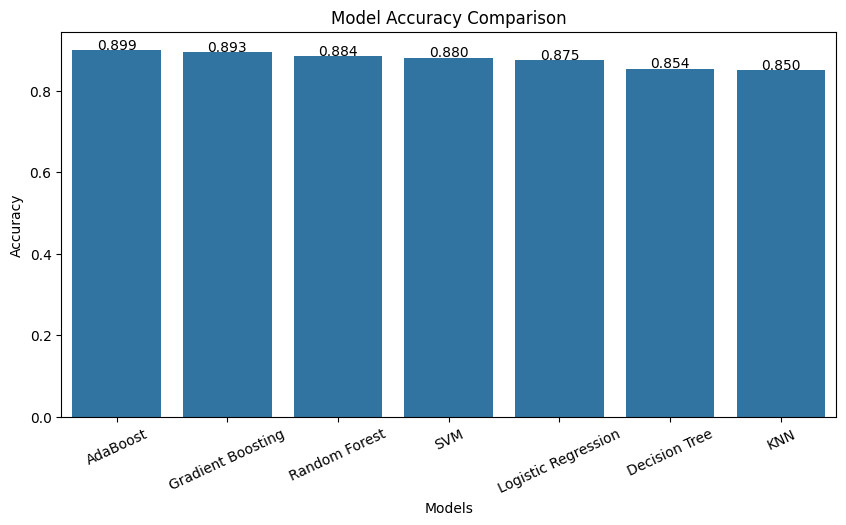

In [66]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values( by="Accuracy", ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(data=results_df, x="Model", y="Accuracy")

plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=25)

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(
        i,
        value+0.002,
        f"{value:.3f}",
        ha='center'
    )

plt.show()

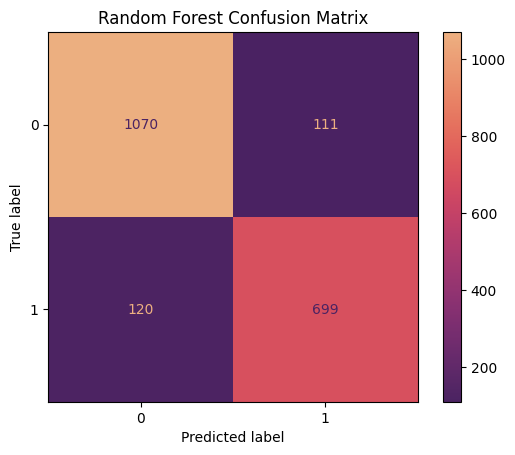

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    models['Random Forest'],
    X_test,
    y_test,
    cmap="flare_r"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

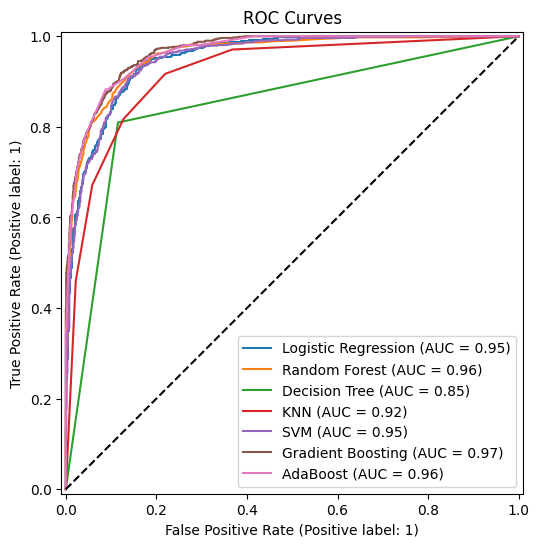

In [72]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test ,ax=plt.gca(), name=name)

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curves")
plt.show()

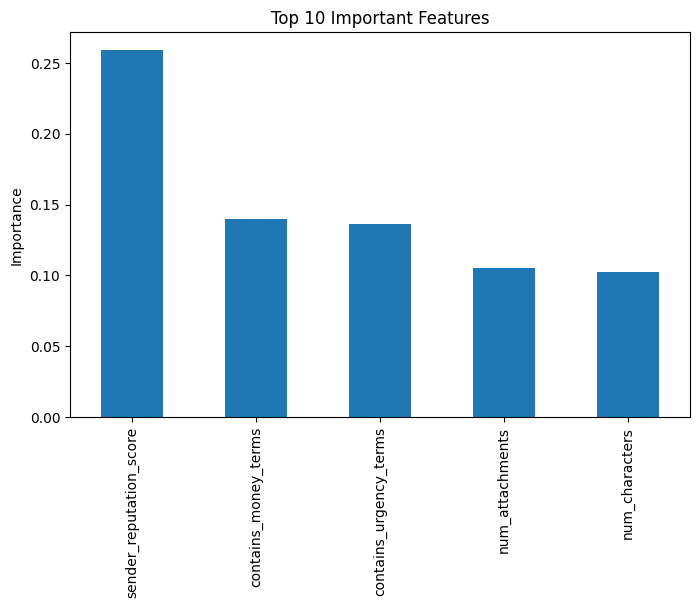

In [75]:
importance = pd.Series(
    models['Random Forest'].feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
).head(5)

plt.figure(figsize=(8,5))

importance.plot(kind='bar')

plt.title("Top 10 Important Features")
plt.ylabel("Importance")

plt.show()